In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
data_path = "/Users/lubhanamutha/Desktop/BMS/NASA/processed_soc"


csv_files = sorted([
    os.path.join(data_path, f)
    for f in os.listdir(data_path)
    if f.endswith(".csv")
])

print("Total cycles:", len(csv_files))


Total cycles: 341


In [3]:
cycles = []   # list of dataframes (ONE PER CYCLE)

for file in csv_files:
    df_cycle = pd.read_csv(file)

    # normalize mode column
    df_cycle['mode'] = df_cycle['mode'].astype(str).str.lower().str.strip()

    # discharge only
    df_dis = df_cycle[df_cycle['mode'] == 'discharge'].reset_index(drop=True)

    # skip empty cycles
    if len(df_dis) > 0:
        cycles.append(df_dis)

print("Valid discharge cycles:", len(cycles))
df_cycle.head()

Valid discharge cycles: 171


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time_uniform,dV_dt,dT_dt,SOC,mode
0,4.169461,-0.000586,6.383970,0.0004,0.000,0.0,NaN,NaN,1.000000,discharge
1,4.169424,-0.000809,6.385649,0.0004,0.465,1.0,-0.000037,0.001678,1.000000,discharge
2,4.169387,-0.001031,6.387327,0.0004,0.930,2.0,-0.000037,0.001678,1.000000,discharge
3,4.169350,-0.001254,6.389006,0.0004,1.395,3.0,-0.000037,0.001678,0.999999,discharge
4,4.169313,-0.001476,6.390684,0.0004,1.860,4.0,-0.000037,0.001678,0.999999,discharge


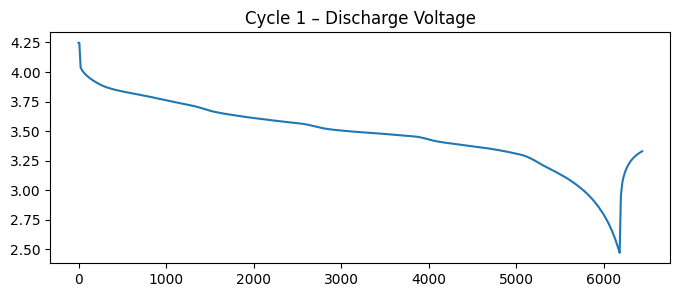

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))
plt.plot(cycles[0]['Voltage_measured'])
plt.title("Cycle 1 – Discharge Voltage")
plt.show()


In [5]:
import numpy as np

class BatteryECM:
    def __init__(self, Q, R0, R1, C1, dt, ocv_func, soc_init=1.0):
        self.Q = Q
        self.R0 = R0
        self.R1 = R1
        self.C1 = C1
        self.dt = dt
        self.ocv_func = ocv_func

        # states
        self.SOC = soc_init
        self.V_RC = 0.0

    def step(self, I):
        # SOC update (discharge current > 0)
        self.SOC -= (I * self.dt) / (3600 * self.Q)
        self.SOC = np.clip(self.SOC, 0, 1)

        # RC dynamics
        alpha = np.exp(-self.dt / (self.R1 * self.C1))
        self.V_RC = alpha * self.V_RC + self.R1 * (1 - alpha) * I

        # Voltage
        OCV = self.ocv_func(self.SOC)
        V_ecm = OCV - I * self.R0 - self.V_RC

        return self.SOC, self.V_RC, OCV, V_ecm


In [6]:
def ocv_func(soc):
    return 3.0 + 1.2 * soc   # will be replaced later



In [7]:
V_CUTOFF = 2.7

cycle = cycles[0]   # first discharge cycle

# Apply cutoff
cycle = cycle[cycle['Voltage_measured'] > V_CUTOFF].reset_index(drop=True)

time = cycle['Time_uniform'].values
current = -cycle['Current_measured'].values
voltage = cycle['Voltage_measured'].values

dt = np.mean(np.diff(time))
print("dt =", dt)
soc = cycle['SOC'].values
voltage = cycle['Voltage_measured'].values

mask = (soc > 0.15) & (soc < 0.95)

soc_use = soc[mask]
voltage_use = voltage[mask]


dt = 1.0191607284243864


In [27]:
N1 = 5
N2 = 50   # small window after start

I1 = np.mean(current[:N1])
I2 = np.mean(current[N1:N2])

V1 = np.mean(voltage[:N1])
V2 = np.mean(voltage[N1:N2])

R0_est = (V1 - V2) / (I2 - I1)

print("Estimated R0 (slope-based):", R0_est)


Estimated R0 (slope-based): 0.22331567850603876


In [18]:
Q_rated = 2.3      # Ah
R0_init = 0.02     # Ohm (fixed baseline)
R1_init = 0.01
C1_init = 2000

ecm = BatteryECM(
    Q=Q_rated,
    R0=R0_init,
    R1=R1_init,
    C1=C1_init,
    dt=dt,
    ocv_func=ocv_func,
    soc_init=1.0
)


In [19]:
SOC_list = []
V_RC_list = []
OCV_list = []
V_ECM_list = []
V_error_list = []

for I, V_meas in zip(current, voltage):
    SOC, V_RC, OCV, V_ECM = ecm.step(I)

    SOC_list.append(SOC)
    V_RC_list.append(V_RC)
    OCV_list.append(OCV)
    V_ECM_list.append(V_ECM)
    V_error_list.append(V_meas - V_ECM)


In [20]:
import numpy as np

num_bins = 50
bins = np.linspace(soc_use.min(), soc_use.max(), num_bins)

soc_bin_centers = []
voltage_bin_means = []

for i in range(len(bins) - 1):
    idx = (soc_use >= bins[i]) & (soc_use < bins[i+1])
    if np.sum(idx) > 10:  # enough points
        soc_bin_centers.append(np.mean(soc_use[idx]))
        voltage_bin_means.append(np.mean(voltage_use[idx]))

soc_bin_centers = np.array(soc_bin_centers)
voltage_bin_means = np.array(voltage_bin_means)


In [21]:
coeffs = np.polyfit(soc_bin_centers, voltage_bin_means, deg=5)
ocv_poly = np.poly1d(coeffs)

def ocv_func_fitted(soc):
    return ocv_poly(soc)


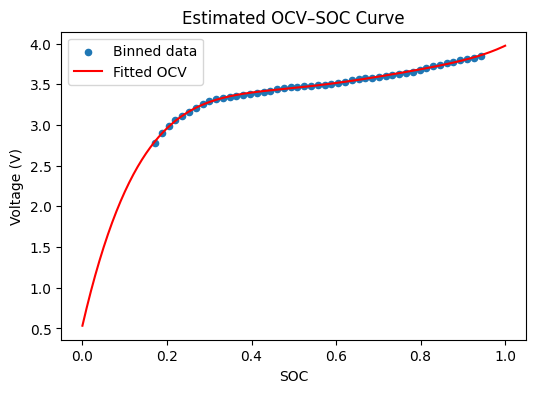

In [13]:
import matplotlib.pyplot as plt

soc_grid = np.linspace(0, 1, 200)

plt.figure(figsize=(6,4))
plt.scatter(soc_bin_centers, voltage_bin_means, s=20, label="Binned data")
plt.plot(soc_grid, ocv_func_fitted(soc_grid), 'r', label="Fitted OCV")
plt.xlabel("SOC")
plt.ylabel("Voltage (V)")
plt.title("Estimated OCV–SOC Curve")
plt.legend()
plt.show()


In [22]:
cycle['SOC_ECM'] = SOC_list
cycle['V_RC'] = V_RC_list
cycle['OCV_ECM'] = OCV_list
cycle['V_ECM'] = V_ECM_list
cycle['V_error'] = V_error_list


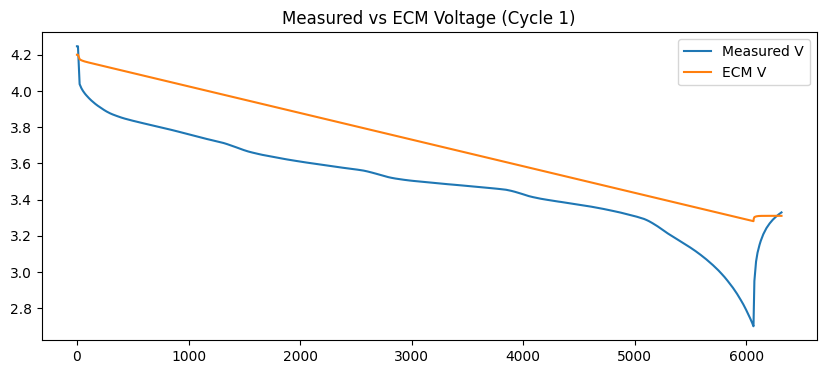

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(voltage, label='Measured V')
plt.plot(cycle['V_ECM'], label='ECM V')
plt.legend()
plt.title("Measured vs ECM Voltage (Cycle 1)")
plt.show()


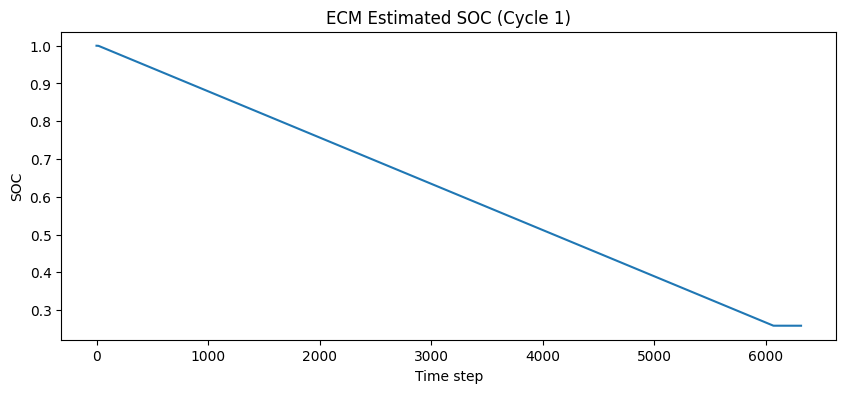

In [24]:
plt.figure(figsize=(10,4))
plt.plot(cycle['SOC_ECM'])
plt.title("ECM Estimated SOC (Cycle 1)")
plt.ylabel("SOC")
plt.xlabel("Time step")
plt.show()
